# 量子电路 AI 编译器 - Colab GPU 训练一键通
只需依次点击每个代码块的运行按钮（或者点击菜单栏：`代码执行程序` -> `全部运行`）。
**注意：请确保上方菜单栏 `代码执行程序` -> `更改运行时类型` 中已选择 `T4 GPU`。**

In [1]:
# 1. 环境检测与自动防断联配置
import torch
import IPython

print(f'PyTorch: {torch.__version__}')
print(f'CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

# 自动向浏览器注入防闲置断联 JS 代码（全自动，您无需任何操作）
display(IPython.display.Javascript('''
function keepAlive() {
  document.querySelector("colab-connect-button")?.click();
  console.log("Auto-reconnect triggered: " + new Date().toLocaleTimeString());
}
setInterval(keepAlive, 60000);
'''))
print('\n✅ 防断联机制已自动注入后台！')

PyTorch: 2.10.0+cpu
CUDA: False


<IPython.core.display.Javascript object>


✅ 防断联机制已自动注入后台！


In [2]:
# 2. 安装项目依赖库
!pip install -q qiskit==2.3.1 qiskit-aer==0.17.2 gymnasium==1.2.3 rustworkx
!pip install -q torch_geometric
import torch
!pip install -q torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-{torch.__version__}.html
print('\n✅ 依赖库安装完毕！')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 78.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 83.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 71.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 27.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.4/682.4 kB 15.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 52.1 MB/s eta 0:00:00

✅ 依赖库安装完毕！


In [3]:
!rm -rf ZJU-Quantum-Compiler
!git clone https://github.com/qqyyqq812/ZJU-Quantum-Compiler.git

Cloning into 'ZJU-Quantum-Compiler'...
remote: Enumerating objects: 423, done.
remote: Counting objects: 100% (423/423), done.
remote: Compressing objects: 100% (313/313), done.
remote: Total 423 (delta 177), reused 339 (delta 93), pack-reused 0 (from 0)
Receiving objects: 100% (423/423), 28.86 MiB | 17.06 MiB/s, done.
Resolving deltas: 100% (177/177), done.


### 💡 【断点画图监控机制】关于如何查看曲线
请切记：**Colab 是串行执行的！**。这意味着下方的训练格子（格子 4）如果不跑完，它就永远不会执行下方的监控画图（格子 5）。
如果您想中途看运行得怎么样了：
1. 鼠标悬停在**格子 4 (启动 GPU 训练)** 左侧，点击 **停止按钮 (■)** 打断训练。
2. 往下滑，点击运行**格子 5 (📉 训练可视化监控)**。
3. 看完曲线之后，重新回到此格，**点击格子 4 左侧的播放按钮 (▶)**。它会利用超强悍的无损断点续传机制，从打断的那一局继续跑下去，不浪费一丝一毫算力。

In [6]:
%cd /content/ZJU-Quantum-Compiler

/content/ZJU-Quantum-Compiler


In [13]:
# 4. 挂载 Google Drive 并启动全量 GPU 训练
from google.colab import drive
import os

# 挂载云盘（会弹出 Google 授权提示，请点击允许，确保断开连接也不会丢失模型）
drive.mount('/content/drive')
DRIVE_SAVE = '/content/drive/MyDrive/quantum_train/models'
os.makedirs(DRIVE_SAVE, exist_ok=True)
print(f'\n✅ 模型存放云盘目录已就绪: {DRIVE_SAVE}')

# 硬链接，将原本的输出目录映射到 Google Drive
!mkdir -p models
!rm -rf models/v9_tokyo20_fallback
!ln -s /content/drive/MyDrive/quantum_train/models models/v9_tokyo20_fallback

print('\n\n================ 🚀 启动 GPU 训练 ================')
!bash run_train_v9_20Q_fallback.sh resume

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

✅ 模型存放云盘目录已就绪: /content/drive/MyDrive/quantum_train/models


================ 🚀 启动 GPU 训练 ================
🚀 V9 20Q IBM Tokyo 训练
   拓扑: ibm_tokyo
   Episodes: 50000
   保存目录: models/v9_tokyo20_fallback
   🔄 从最新 checkpoint 恢复: models/v9_tokyo20_fallback/checkpoint_ep2200.pt
   V8 奖励: gate=1.0, swap=-1.0, done=20.0, dist=0.5
   V8 随机初始映射: 已启用
🖥️  训练设备: cpu
   拓扑限制: 20Q → 最大课程阶段 4 (master)
🔄 课程状态恢复: Stage 0 (warm-up)
🔄 完整 checkpoint 恢复: models/v9_tokyo20_fallback/checkpoint_ep2200.pt (ep2200)
📚 课程学习已启用: 5 个可用阶段 (共 5 阶段)
   当前阶段: warm-up (3Q)
📜 历史记录恢复: 3400 条已有记录
🚀 V7 训练启动: ibm_tokyo (20Q), 50000 episodes
   从 episode 2200 继续
   Rollout steps: 256, LR: 0.0003→1e-05, Entropy: 0.05→0.001
  [  2300/50000] [Stage 0:warm-up] R=  -62.7 SWAP= 60.2 LR=2.9e-04 H=0.048 (19 ep/s)
  💾 Checkpoint: models/v9_tokyo20_fallback/checkpoint_ep2300.pt (Stage 0)
  [  2400/50000] [Sta

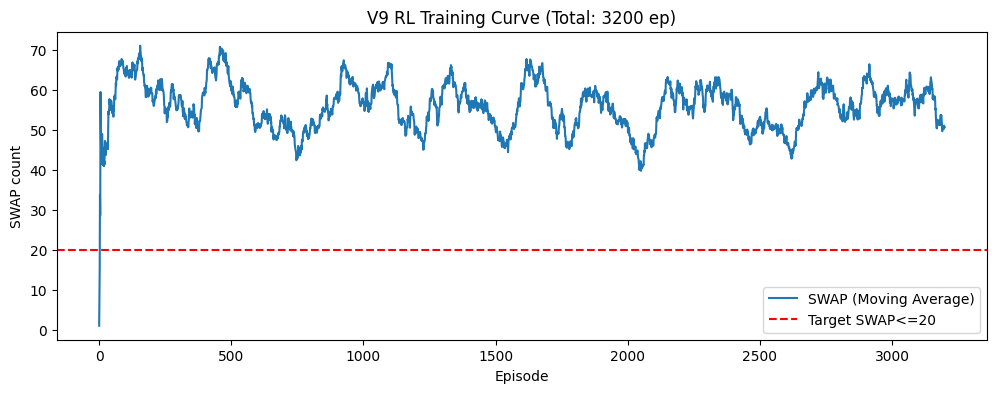

In [11]:
# 5. 📉 训练可视化监控
# (可以在训练进行中，随时按照上方 markdown 的指导，随时停止上面的训练，运行本代码块看图！画完以后立刻继续上面的代码块以接着训练！)
import json, matplotlib.pyplot as plt, numpy as np
import os

DRIVE_SAVE = '/content/drive/MyDrive/quantum_train/models'
history_file = f'{DRIVE_SAVE}/history_v7_ibm_tokyo.json'

if os.path.exists(history_file):
    with open(history_file) as f:
        h = json.load(f)
    s = h['episode_swaps']
    window = 100
    avg = [np.mean(s[max(0,i-window):i+1]) for i in range(len(s))]
    plt.figure(figsize=(12,4))
    plt.plot(avg, label='SWAP (Moving Average)')
    plt.axhline(y=20, color='r', linestyle='--', label='Target SWAP<=20')
    plt.xlabel('Episode'); plt.ylabel('SWAP count')
    plt.legend(); plt.title(f'V9 RL Training Curve (Total: {len(s)} ep)')
    plt.show()
else:
    print('⚠️ 暂未找到训练日志文件，请稍等训练写入历史后再运行。')